# 02 - Baseline Reproducible Training

Baseline transfer learning voi EfficientNet-B0/ResNet18.

In [1]:
import sys
from pathlib import Path
import torch
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.append(str(ROOT / 'src'))

from flowers102.data import build_dataloaders
from flowers102.models import create_model
from flowers102.train import fit, TrainConfig
from flowers102.utils import set_seed, save_json

set_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
train_loader, valid_loader, test_loader, train_ds, valid_ds, test_ds = build_dataloaders(
    data_dir="/home/nguyenhuynh/Documents/deep-learning/dataset/flower_data",
    batch_size=32,
    num_workers=0,
    image_size=224,
    use_augmentation=True,
)
num_classes = len(train_ds.classes)
print('train/valid/test:', len(train_ds), len(valid_ds), len(test_ds))
print('num_classes:', num_classes)

train/valid/test: 6534 818 819
num_classes: 102


In [3]:
model = create_model('efficientnet_b0', num_classes=num_classes, pretrained=True)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=12)

cfg = TrainConfig(
    epochs=12,
    device=device,
    checkpoint_path=str(ROOT / 'checkpoints' / 'baseline_best.pth'),
    early_stopping_patience=4,
)

history = fit(model, train_loader, valid_loader, criterion, optimizer, scheduler, cfg)
history.keys()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/nguyenhuynh/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:02<00:00, 10.4MB/s]


[Epoch 1/12]  train_loss=2.2787  train_top1=0.5473  valid_loss=0.4750  valid_top1=0.9169  valid_top5=0.9902  lr=0.000295
[Epoch 2/12]  train_loss=0.5737  train_top1=0.8725  valid_loss=0.1712  valid_top1=0.9670  valid_top5=0.9951  lr=0.000280
[Epoch 3/12]  train_loss=0.3771  train_top1=0.9123  valid_loss=0.1288  valid_top1=0.9731  valid_top5=0.9988  lr=0.000256
[Epoch 4/12]  train_loss=0.3089  train_top1=0.9233  valid_loss=0.0965  valid_top1=0.9817  valid_top5=0.9976  lr=0.000225
[Epoch 5/12]  train_loss=0.2623  train_top1=0.9365  valid_loss=0.0977  valid_top1=0.9817  valid_top5=0.9976  lr=0.000189
[Epoch 6/12]  train_loss=0.2002  train_top1=0.9513  valid_loss=0.0834  valid_top1=0.9866  valid_top5=0.9976  lr=0.000150
[Epoch 7/12]  train_loss=0.1841  train_top1=0.9524  valid_loss=0.0781  valid_top1=0.9780  valid_top5=0.9988  lr=0.000111
[Epoch 8/12]  train_loss=0.1493  train_top1=0.9625  valid_loss=0.0661  valid_top1=0.9866  valid_top5=0.9988  lr=0.000075
[Epoch 9/12]  train_loss=0.1470 

dict_keys(['train_loss', 'train_top1', 'valid_loss', 'valid_top1', 'valid_top5'])

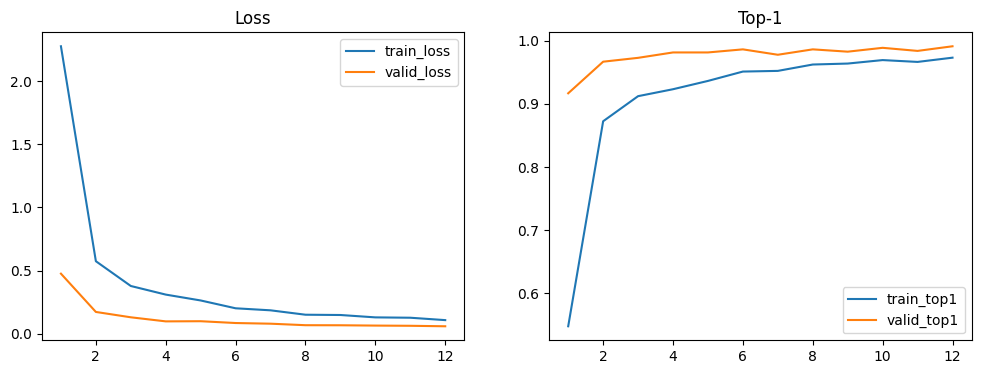

In [4]:
epochs = list(range(1, len(history['train_loss']) + 1))
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, history['train_loss'], label='train_loss')
plt.plot(epochs, history['valid_loss'], label='valid_loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(epochs, history['train_top1'], label='train_top1')
plt.plot(epochs, history['valid_top1'], label='valid_top1')
plt.legend()
plt.title('Top-1')
plt.show()

In [5]:
save_json(history, ROOT / 'reports' / 'baseline_history.json')
print('saved:', (ROOT / 'reports' / 'baseline_history.json').resolve())
print('checkpoint:', (ROOT / 'checkpoints' / 'baseline_best.pth').resolve())

saved: /home/nguyenhuynh/Documents/deep-learning/quangbinh/cv/reports/baseline_history.json
checkpoint: /home/nguyenhuynh/Documents/deep-learning/quangbinh/cv/checkpoints/baseline_best.pth
